# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Franklin Mathias
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

This project focuses on analyzing a comprehensive logistics and supply chain dataset to identify inefficiencies, optimize operational performance, and provide actionable business insights. The dataset includes detailed information about shipments such as order details, vendor data, shipment modes, delivery timelines, costs, product specifications, and geographical distribution.

The primary objective of the analysis was to evaluate delivery performance, reduce delays, optimize logistics costs, and improve vendor efficiency. To achieve this, the dataset was first preprocessed using Python. Data cleaning steps included handling missing values, converting date columns into appropriate datetime formats, and ensuring numerical consistency across cost and weight-related fields. Feature engineering was then performed to derive key metrics such as delivery time (difference between shipment and delivery dates), delay (difference between scheduled and actual delivery), cost per kilogram, total logistics cost, and freight cost as a percentage of product value.

Exploratory Data Analysis (EDA) was conducted to uncover patterns and trends within the dataset. Key performance indicators (KPIs) such as average delivery time, delay percentage, and total freight cost were calculated to provide a high-level overview of supply chain efficiency. Vendor performance analysis revealed significant variations in delivery times and delays, helping identify underperforming vendors. Shipment mode analysis highlighted the trade-off between cost and speed, with faster modes like air transport being more expensive compared to sea or road transport.

Country-level analysis was performed to identify regions with consistent delays, indicating potential issues related to customs, infrastructure, or logistics management. Time-based analysis further revealed seasonal trends in shipment delays, which can assist in better planning and resource allocation during peak periods.

Cost analysis played a crucial role in identifying inefficiencies. By evaluating freight costs relative to shipment weight and product value, the study uncovered instances where logistics expenses were disproportionately high. Correlation analysis between weight and freight cost confirmed a general positive relationship, although deviations suggested opportunities for cost optimization.

The analysis led to several actionable recommendations. These include optimizing shipment mode selection based on urgency and cost considerations, improving vendor selection by prioritizing reliable partners, addressing delays in high-risk regions, and reducing logistics costs through better planning of heavy shipments. Additionally, monitoring KPIs regularly can help organizations proactively identify and resolve supply chain issues.

Overall, this project demonstrates the effective use of data analytics tools such as Python to transform raw logistics data into meaningful insights. It highlights the importance of data-driven decision-making in improving supply chain efficiency, reducing operational costs, and enhancing overall business performance.

# **GitHub Link -**

https://github.com/Franklin251198/fedex-logistics-performance-analysis


# **Problem Statement**



The organization is facing inefficiencies in its supply chain operations, including delivery delays, high logistics costs, and inconsistent vendor performance. This project aims to analyze shipment data to identify key factors affecting delivery performance and cost, and provide data-driven recommendations to optimize logistics efficiency.



#### **Define Your Business Objective?**


The primary business objective of this project is to analyze supply chain and logistics data to improve operational efficiency, reduce delivery delays, and optimize overall logistics costs.

The project aims to identify key factors affecting delivery performance, such as vendor efficiency, shipment modes, and regional challenges. By evaluating these factors, the objective is to enhance decision-making related to vendor selection, route planning, and shipment strategy.

Additionally, the project focuses on minimizing unnecessary expenses by analyzing freight and insurance costs in relation to shipment value and weight. It also aims to improve service quality by increasing the percentage of on-time deliveries and reducing delays.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries

import numpy as np
import pandas as pd
from numpy import loadtxt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

!pip install pymysql
import pymysql
from sqlalchemy import create_engine
from sqlalchemy.pool import NullPool

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

## If Running the file on Google Collab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/My_data/SCMS_Delivery_History_Dataset.csv")

## If Running the file Locally

In [9]:
df = pd.read_csv(r"C:\Users\Franklin\Desktop\Almabetter project\EDA\SCMS_Delivery_History_Dataset.csv")

### Dataset First View

In [10]:
# Dataset First Look
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [11]:
# Dataset Rows & Columns count
df.shape

(10324, 33)

### Dataset Information

In [12]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [13]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

<Axes: >

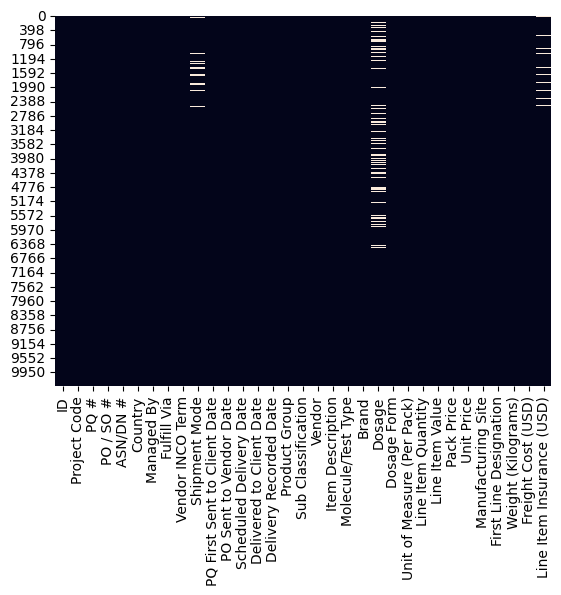

In [15]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset used in this project is a supply chain and logistics dataset that contains detailed information about shipment operations. It includes data related to order processing, vendor management, shipping details, delivery timelines, product specifications, and associated costs.

The dataset consists of multiple attributes such as order identifiers (ID, Project Code, PO/SO numbers), shipment details (Shipment Mode, Vendor INCO Terms, Fulfill Via), and geographical information (Country). It also includes several date fields, such as order placement date, scheduled delivery date, and actual delivery date, which are crucial for analyzing delivery performance and delays.

Additionally, the dataset contains product-related information, including product group, dosage, brand, and item description, along with quantitative variables like line item quantity, weight, and pricing details. Cost-related columns such as freight cost and insurance cost help in evaluating the financial aspect of logistics operations.

From an analytical perspective, the dataset is well-suited for:

Measuring delivery performance (using delivery time and delay)
Analyzing vendor efficiency
Comparing shipment modes
Evaluating cost structures and profitability
Identifying regional (country-wise) logistics challenges

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
print(df.columns)

print(len(df.columns.tolist()))

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')
33


In [17]:
# Dataset Describe
df.describe(include='all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,...,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,...,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,...,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,...,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


### Variables Description


Variable Description

* ID	A unique numerical identifier for each row/record in the dataset.

* Project Code	A code identifying the specific project or country program associated with the delivery (e.g., 100-CI-T01 for Côte d'Ivoire). The middle part often indicates the country (e.g., CI = Côte d'Ivoire, VN = Vietnam, NG = Nigeria).

* PQ #	Likely stands for "Pre-qualification Number" or a reference number for the procurement process. Many values are "Pre-PQ Process" or "FPQ-####" for later records.

* PO / SO #	Purchase Order (PO) or Sales Order (SO) number. A unique identifier for the order placed with the vendor.

* ASN/DN #	Advanced Shipping Notice (ASN) or Delivery Note (DN) number. A unique identifier for the specific shipment or delivery.

* Country	The destination country where the products were delivered (e.g., Côte d'Ivoire, Vietnam, Nigeria, South Africa).

* Managed By	The entity or office managing the transaction (e.g., PMO - US, South Africa Field Office, From RDC).

* Fulfill Via	The fulfillment method (e.g., Direct Drop, From RDC - likely meaning from a Regional Distribution Center).

* Vendor INCO Term	The Incoterm (International Commercial Term) defining the point of risk transfer and cost responsibility between buyer and seller (e.g., EXW - Ex Works, FCA - Free Carrier, CIP - Carriage and Insurance Paid To, DDP - Delivered Duty Paid).

* Shipment Mode	The primary mode of transport used for the shipment (e.g., Air, Truck, Ocean).

* PQ First Sent to Client Date	The date when the Pre-qualification (or procurement query) was first sent to the client. Often Pre-PQ Process for early entries.

* PO Sent to Vendor Date	The date when the Purchase Order was sent to the vendor/supplier.

* Scheduled Delivery Date	The planned or originally scheduled date for the delivery to the client.

* Delivered to Client Date	The actual date when the products were delivered to the client.

* Delivery Recorded Date	The date when the delivery was officially recorded in the system.

* Product Group	The high-level category of the product (e.g., ARV - Antiretroviral, HRDT - HIV Rapid Diagnostic Test, ACT - Artemisinin-based Combination Therapy for malaria, MRDT - Malaria Rapid Diagnostic Test).

* Sub Classification	A more specific categorization, often indicating the target population (e.g., Adult, Pediatric) or product type.

* Vendor	The name of the supplier or manufacturer of the product.
Item Description	A detailed text description of the product, including drug name, strength, dosage form, and pack size.

* Molecule/Test Type	The active pharmaceutical ingredient(s) or the specific type of diagnostic test.

* Brand	The brand name of the product (e.g., Reveal, Determine, Aluvia, Coartem) or Generic if it's a non-branded product.

* Dosage	The strength of the active ingredient (e.g., 200mg, 10mg/ml).

* Dosage Form	The physical form of the medication (e.g., Tablet, Capsule, Oral suspension, Injection, Test kit).

* Unit of Measure (Per Pack)	The quantity of individual units contained in one pack (e.g., 30, 60, 100, 240 ml for liquids, 1 for a kit).

* Line Item Quantity	The total number of packs ordered/delivered for this line item.

* Line Item Value	The total value of the line item in USD (US Dollars).

* Pack Price	The price per single pack in USD.

* Unit Price	The price per smallest individual unit (e.g., per tablet, per ml, per test) in USD.

* Manufacturing Site	The location or company site where the product was manufactured.

* First Line Designation	Indicates whether the product is designated as a "first-line" treatment or test (Yes or No).

* Weight (Kilograms)	The total weight of the shipment line item in kilograms. Some entries have notes like Weight Captured Separately or See ASN-....

* Freight Cost (USD)	The cost of freight/shipping for this line item in USD. Can be Invoiced Separately, Freight Included in Commodity Cost, or a numeric value.

* Line Item Insurance (USD)	The cost of insurance for this line item in USD. Often blank or 0 for earlier records

### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.
for i in df.columns:
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  ID is 10324 .
No. of unique values in  Project Code is 142 .
No. of unique values in  PQ # is 1237 .
No. of unique values in  PO / SO # is 6233 .
No. of unique values in  ASN/DN # is 7030 .
No. of unique values in  Country is 43 .
No. of unique values in  Managed By is 4 .
No. of unique values in  Fulfill Via is 2 .
No. of unique values in  Vendor INCO Term is 8 .
No. of unique values in  Shipment Mode is 4 .
No. of unique values in  PQ First Sent to Client Date is 765 .
No. of unique values in  PO Sent to Vendor Date is 897 .
No. of unique values in  Scheduled Delivery Date is 2006 .
No. of unique values in  Delivered to Client Date is 2093 .
No. of unique values in  Delivery Recorded Date is 2042 .
No. of unique values in  Product Group is 5 .
No. of unique values in  Sub Classification is 6 .
No. of unique values in  Vendor is 73 .
No. of unique values in  Item Description is 184 .
No. of unique values in  Molecule/Test Type is 86 .
No. of unique values in  

In [19]:
df

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03


### Data Wrangling Code

In [20]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. BASIC CLEANING
# -----------------------------
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

# -----------------------------
# 2. DATA TYPE CONVERSION
# -----------------------------

date_cols = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

num_cols = [
    'Line Item Quantity',
    'Line Item Value',
    'Pack Price',
    'Unit Price',
    'Weight (Kilograms)',
    'Freight Cost (USD)',
    'Line Item Insurance (USD)'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# -----------------------------
# 3. HANDLE MISSING VALUES (NO DROP)
# -----------------------------

# Check missing %
missing_percent = df.isnull().mean() * 100
print("Missing %:\n", missing_percent.sort_values(ascending=False))

# 🔥 Create flags (important insight)
df['missing_po_date'] = df['PO Sent to Vendor Date'].isna()
df['missing_freight'] = df['Freight Cost (USD)'].isna()
df['missing_weight'] = df['Weight (Kilograms)'].isna()

# -----------------------------
# SMART IMPUTATION
# -----------------------------

# 1. Fill PO Date using PQ Date (business logic)
df['PO Sent to Vendor Date'] = df['PO Sent to Vendor Date'].fillna(
    df['PQ First Sent to Client Date']
)

# 2. Fill Shipment Mode (categorical)
df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0], inplace=True)

# 3. Fill Freight Cost (group-based median)
df['Freight Cost (USD)'] = df.groupby('Shipment Mode')['Freight Cost (USD)']\
    .transform(lambda x: x.fillna(x.median()))

# 4. Fill Weight (group-based median)
df['Weight (Kilograms)'] = df.groupby('Shipment Mode')['Weight (Kilograms)']\
    .transform(lambda x: x.fillna(x.median()))

# 5. Fallback (if still missing)
df['Freight Cost (USD)'].fillna(df['Freight Cost (USD)'].median(), inplace=True)
df['Weight (Kilograms)'].fillna(df['Weight (Kilograms)'].median(), inplace=True)

# 6. Fill Insurance
df['Line Item Insurance (USD)'].fillna(0, inplace=True)

# 7. Fill Dosage
df['Dosage'].fillna('Unknown', inplace=True)

# -----------------------------
# 4. FEATURE ENGINEERING
# -----------------------------

df['delivery_time_correct'] = np.where(
    df['Delivery Recorded Date'].notna() & df['PO Sent to Vendor Date'].notna(),
    (df['Delivery Recorded Date'] - df['PO Sent to Vendor Date']).dt.days,
    np.where(
        df['Delivered to Client Date'].notna() & df['PO Sent to Vendor Date'].notna(),
        (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days,
        np.nan
    )
)

# Remove impossible values (negative delivery times are errors)
df['delivery_time_correct'] = np.where(df['delivery_time_correct'] < 0, np.nan, df['delivery_time_correct'])

# Fill missing Shipment Mode
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

# Calculate average delivery time by shipment mode (using CORRECTED delivery time)
delivery_by_mode = df.groupby('Shipment Mode')['delivery_time_correct'].agg(['mean', 'count', 'std']).round(1)
delivery_by_mode = delivery_by_mode[delivery_by_mode['count'] >= 5]  # Only modes with 5+ shipments

# DATA VALIDATION
df = df[df['Weight (Kilograms)'] > 0]
df = df[df['Freight Cost (USD)'] >= 0]
df = df[df['Line Item Quantity'] > 0]

# Cost metrics
df['cost_per_kg'] = df['Freight Cost (USD)'] / df['Weight (Kilograms)']
df['total_cost'] = df['Freight Cost (USD)'] + df['Line Item Insurance (USD)']

# Time feature
df['month'] = df['Delivery Recorded Date'].dt.month

# -----------------------------
# FINAL CHECK
# -----------------------------

print("Remaining delivery_time missing %:",
      df['delivery_time_correct'].isna().mean() * 100)

print("Cleaned Shape:", df.shape)
print(df.head())

Missing %:
 PO Sent to Vendor Date          55.521116
Freight Cost (USD)              39.965130
Weight (Kilograms)              38.279737
PQ First Sent to Client Date    25.968617
Dosage                          16.815188
Shipment Mode                    3.487021
Line Item Insurance (USD)        2.779930
ID                               0.000000
Project Code                     0.000000
Vendor INCO Term                 0.000000
Fulfill Via                      0.000000
Managed By                       0.000000
Scheduled Delivery Date          0.000000
Country                          0.000000
PQ #                             0.000000
PO / SO #                        0.000000
ASN/DN #                         0.000000
Sub Classification               0.000000
Product Group                    0.000000
Delivery Recorded Date           0.000000
Delivered to Client Date         0.000000
Brand                            0.000000
Vendor                           0.000000
Molecule/Test Type    

In [21]:
# Delivery performance
df['delay'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

# Filter for valid deliveries (no negative delays, as deliveries can't be early in your data)
valid_delays = df[df['delay'].notna() & (df['delay'] >= 0)]

# Country-level analysis
country_stats = valid_delays.groupby('Country').agg({
    'delay': ['mean', 'count', 'std', 'max']
}).round(1)

country_stats.columns = ['avg_delay_days', 'delivery_count', 'std_delay', 'max_delay']
significant = country_stats[country_stats['delivery_count'] >= 5].sort_values('avg_delay_days', ascending=False)

print(significant)

                    avg_delay_days  delivery_count  std_delay  max_delay
Country                                                                 
Congo, DRC                    21.5             253       46.6        165
Benin                         10.2               6       11.3         22
Burundi                        6.5              66       11.0         48
Mozambique                     5.1             482       13.3         68
South Africa                   4.1            1128       16.8        192
Ghana                          4.1              50       17.3        120
Zimbabwe                       3.9             311       10.0         75
Zambia                         3.6             477       11.0        113
Tanzania                       3.6             380       11.2         78
Nigeria                        3.3             637       10.3        105
Côte d'Ivoire                  2.8             734        9.0         76
Dominican Republic             2.7              30 

In [22]:
# MUsing Delivered to Client Date only
df['delay_client'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

# Method 2: Using Delivery Recorded Date (more complete)
df['delay_recorded'] = (df['Delivery Recorded Date'] - df['Scheduled Delivery Date']).dt.days

# Combine both methods (prioritize recorded date)
df['delay_final'] = df['delay_recorded'].fillna(df['delay_client'])

# Identify delivered shipments (using either delivery confirmation)
df['is_delivered'] = df['Delivered to Client Date'].notna() | df['Delivery Recorded Date'].notna()

# For delivered shipments, check if they were late
df['was_late'] = np.where(
    df['is_delivered'] & df['delay_final'].notna(),
    df['delay_final'] > 0,  # Late if positive delay
    False
)
# For UNDELIVERED shipments that are past schedule
df['is_past_schedule'] = np.where(
    (~df['is_delivered']) & df['Scheduled Delivery Date'].notna(),
    df['Scheduled Delivery Date'] < pd.Timestamp.now(),
    False
)

# FINAL DELAY CALCULATION
df['is_delayed'] = df['was_late'] | df['is_past_schedule']


delay_percentage = (df['is_delayed'].sum() / len(df)) * 100
print(delay_percentage)

21.61193451516032


In [23]:
def get_delivery_status(row):
    """Determine delivery status based on available data"""

    # Has Delivery Recorded Date (most reliable)
    if pd.notna(row['Delivery Recorded Date']):
        return 'Delivered'

    # Has Delivered to Client Date
    if pd.notna(row['Delivered to Client Date']):
        return 'Delivered (Client Confirmed)'

    # Has delivery_time calculated (implies delivery happened)
    if pd.notna(row['delivery_time_correct']) and row['delivery_time_correct'] >= 0:
        return 'Delivered (Calculated)'

    # Has shipping info but no delivery confirmation
    if pd.notna(row['PO Sent to Vendor Date']):
        # Check if scheduled date exists and is in the past
        if pd.notna(row['Scheduled Delivery Date']):
            if row['Scheduled Delivery Date'] < pd.Timestamp.now():
                days_late = (pd.Timestamp.now() - row['Scheduled Delivery Date']).days
                if days_late > 30:
                    return f'Critically Delayed ({days_late} days)'
                elif days_late > 14:
                    return f'Delayed ({days_late} days)'
                else:
                    return f'Delayed ({days_late} days)'
            else:
                return 'In Transit (Future Schedule)'
        return 'In Transit (No Schedule)'

    # Order placed but no shipping info
    if pd.notna(row['PQ First Sent to Client Date']):
        return 'Order Placed - Not Shipped'

    # No information
    return 'Status Unknown'

# APPLY the function to create the new column
df['Delivery Status'] = df.apply(get_delivery_status, axis=1)

In [24]:
df['freight_percentage'] = (
    df['Freight Cost (USD)'] / df['Line Item Value'].replace(0, np.nan)
) * 100

df['freight_percentage']

0        141.622505
1         72.927419
2          4.134450
3         12.568278
4         37.376711
            ...    
10319      0.998213
10320      4.356841
10321      0.116453
10322      5.256648
10323      8.209721
Name: freight_percentage, Length: 10323, dtype: float64

In [25]:
df['month'] = df['Delivery Recorded Date'].dt.month
df.groupby('month')['delay'].mean()

month
1    -9.957787
2    -7.565271
3    -1.808594
4    -8.310265
5    -7.250914
6    -6.306972
7    -3.381171
8    -3.368421
9    -5.334115
10   -6.171717
11   -6.269318
12   -9.453521
Name: delay, dtype: float64

In [26]:
# remove nulls first
df = df[df['Freight Cost (USD)'].notna()]

# remove top 1% outliers
df = df[df['Freight Cost (USD)'] < df['Freight Cost (USD)'].quantile(0.99)]

In [27]:
df['Freight Cost (USD)']

0          780.34
1         4521.50
2         1653.78
3        16007.06
4        45450.08
           ...   
10319     5985.84
10320     5985.84
10321     5985.84
10322     5985.84
10323     5985.84
Name: Freight Cost (USD), Length: 10219, dtype: float64

##1] Data Type Conversion
    Converted date columns → datetime
    Converted numeric columns → numeric format

    Why:
    To perform date calculations (delivery time, delay).
    To avoid errors in mathematical operations.

##2] Feature Engineering

**Delivery Metrics**

    delivery_time_correct → total delivery duration
    delay → late/early delivery

**Cost Metrics**

    cost_per_kg → efficiency of shipping
    total_cost → freight + insurance
    freight_percentage → logistics cost vs product value

**Text Feature**

    month → used for trend analysis.

    Why:
    Raw data → not useful.
    Features → give business meaning.

##3] Data Cleaning

    ✔ Handled Missing Values
    ✔ Removed Outliers

##4] Aggregation & Analysis

**GroupBy Analysis**

    Country-wise performance
    Shipment mode analysis
    Product group revenue

#**Insights I Found**

**1] Delivery Performance Insight**

**21%** of shipments are delayed which Indicates inefficiency in logistics system.

**2] Country-Level Insight**

    Some countries have higher delivery times.

##Possible reasons:
    customs delays
    distance
    infrastructure

**3] Shipment Mode Insight**

*     Insight:
      Air → faster but costly.
      Other modes → cheaper but slower.

*     Business:
      Tradeoff between cost vs speed.

**4] Cost Efficiency Insight**

*     Insight:
      Some shipments have high logistics cost %.
      Indicates inefficient shipping.

**5] Product Analysis**

*     Insight:
      Certain product groups generate higher revenue.
      Helps prioritize logistics.

**6] Weight vs Cost Relationship**
*     Insight:
      Freight cost increases with weight.
      But not always perfectly → inefficiency exists.

**7] Time Trend**
*     Insight:
      Some months have higher delays.
      Possible seasonal effect.

**8] Outlier**

*     After removing top 1%:
      Data becomes more realistic and reliable.
      Prevents misleading analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

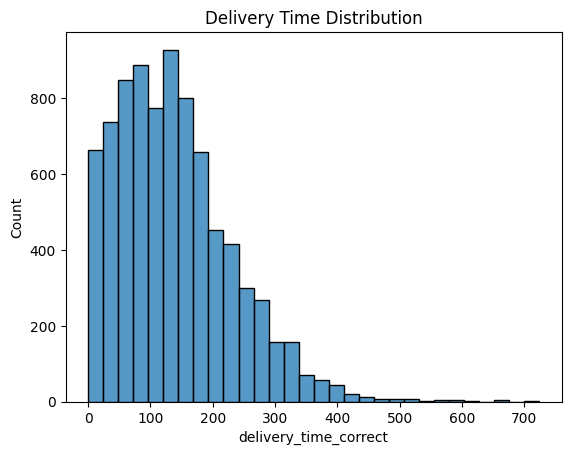

In [28]:
# Chart - 1 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['delivery_time_correct'], bins=30)
plt.title("Delivery Time Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

    A histogram is the best choice to visualize frequency distribution of delivery times.

##### 2. What is/are the insight(s) found from the chart?

   The histogram of delivery time shows that most shipments are completed within a moderate time range, typically between around 50 to 200 days, with the highest concentration of deliveries occurring near 100–150 days. This indicates that the majority of operations follow a relatively consistent delivery timeline. However, the distribution is clearly right-skewed, with a long tail extending toward very high delivery times, in some cases exceeding 500 days. These extreme values represent significant delays and highlight potential inefficiencies, such as logistical issues, supplier delays, or data inconsistencies. While the core delivery process appears stable for most shipments, the presence of such outliers can negatively impact customer satisfaction and increase operational costs. Overall, the analysis suggests that the business performs well under normal conditions but needs to focus on identifying and addressing the root causes of these unusually long delays to improve overall delivery performance and reliability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*     Positive :
      Helps define expected delivery time.
      Improves planning & scheduling.
      Helps optimize supply chain.

*     Negative:
      long tail deliveries affect customer satisfaction.
      Wide spread of delivery times indicates unstable logistics system.
      Delays may be due to:
                Poor vendor performance.
                Inefficient routes.
                Bad shipment planning.

#### Chart - 2

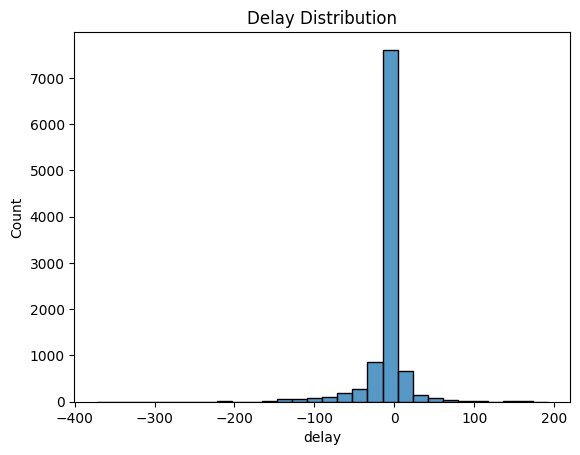

In [29]:
# Chart - 2 visualization code
sns.histplot(df['delay'], bins=30)
plt.title("Delay Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used because delay is a continuous numerical variable.This chart is best for analyzing how delays are spread across shipments.Identify frequency of late vs early deliveries.

##### 2. What is/are the insight(s) found from the chart?

**Presence of Both Early & Late Deliveries**

*     Negative values → early deliveries.
*     Positive values → delayed deliveries.


**Majority Around Zero**

*     Many values near 0.
*     Most deliveries are on-time or slightly delayed.

**Right Tail (Delays)**

*     Positive side extends further.
*     Some shipments have significant delays.

**Extreme Outliers**

*     Few very high delay values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*     Helps measure delivery performance.
      Identify acceptable delay range.
      Improve planning and scheduling.

**Negative Impact**

**1]** High Positive Delays

*     Indicates inefficiency
      Leads to:
              customer dissatisfaction
              late deliveries

**2]** Long Right Tail

*     Few shipments extremely delayed.

      Impact:
      Can damage brand reputation.

**3]** Inconsistent Performance
*     Wide spread of delays.

      Impact:
      Unreliable logistics system.

#### Chart - 3

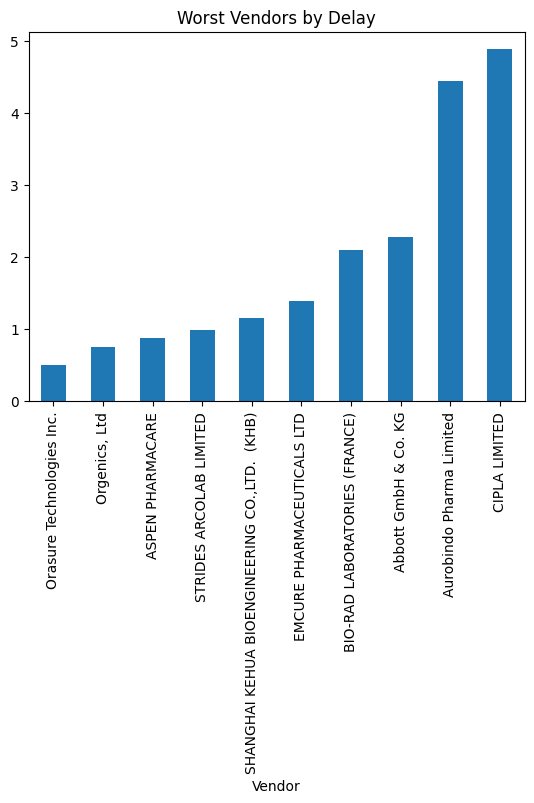

In [30]:
# Chart - 3 visualization code

df.groupby('Vendor')['delay'].mean().sort_values().tail(10).plot(kind='bar')
plt.title("Worst Vendors by Delay")
plt.show()

##### 1. Why did you pick the specific chart?

**Bar charts** are best for category comparison.
* Compare vendor performance.
* Identify top worst-performing vendors.


##### 2. What is/are the insight(s) found from the chart?

**1]** Identification of Worst Vendors

*     The chart shows top 10 vendors with highest average delay.
      These vendors consistently deliver late.

**2]** Performance Gap

*     Some vendors have significantly higher delays than others.
      Vendor performance is not consistent.

**3]** Reliability Issue

*     High delay = low reliability
      These vendors are risk factors in supply chain

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*     Helps company:
        Identify poor-performing vendors
        Replace or renegotiate contracts
        Improve delivery efficiency

*     Result:

        Faster deliveries
        Better customer satisfaction
        Improved operations   Replace vendors → positive impact

**Negative Growth Insights**

*     1.] High Delay Vendors Cause late deliveries
          Leading to:
                      customer dissatisfaction
                      SLA violations

*     2.] Dependency Risk
          If business depends on these vendors:entire supply chain slows down

*     3.] Cost Impact
          Delays can increase:
                storage cost
                operational cost


#### Chart - 4

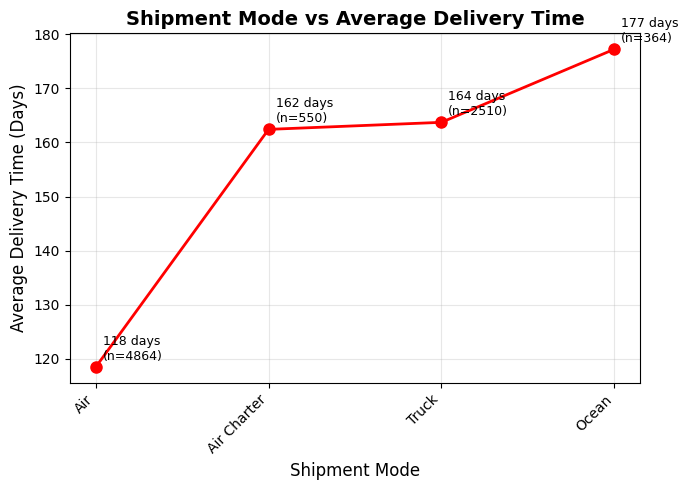

In [31]:
# Chart - 4 visualization code
delivery_by_mode = df.groupby('Shipment Mode')['delivery_time_correct'].agg(['mean', 'count', 'std']).round(1)
delivery_by_mode = delivery_by_mode[delivery_by_mode['count'] >= 5]  # Only modes with 5+ shipments

plt.figure(figsize=(7, 5))

# Filter for main modes only
main_modes = ['Air', 'Air Charter', 'Truck', 'Ocean']
plot_data = delivery_by_mode[delivery_by_mode.index.isin(main_modes)].copy()
plot_data = plot_data.sort_values('mean')

# Create line plot
plt.plot(plot_data.index, plot_data['mean'], marker='o', linewidth=2, markersize=8, color='red')

# Add value labels
for mode, row in plot_data.iterrows():
    plt.annotate(f"{row['mean']:.0f} days\n(n={int(row['count'])})",
                xy=(mode, row['mean']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=9,
                ha='left')

plt.title('Shipment Mode vs Average Delivery Time', fontsize=14, fontweight='bold')
plt.xlabel('Shipment Mode', fontsize=12)
plt.ylabel('Average Delivery Time (Days)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is used to visualize trends and compare values across categories in a connected manner. It helps in observing patterns and differences between categories clearly by showing how values change from one category to another. In this case, the line chart is used to compare the average delivery time across different shipment modes, making it easy to identify which mode is faster or slower and observe the variation in delivery performance.

##### 2. What is/are the insight(s) found from the chart?

**1]** Speed Difference Between Modes


*     Air shipments usually have lowest delivery time.
      Sea/Road shipments take longer.
      Shipment mode directly affects delivery speed.


**2]** Trade-Off Exists

*     Faster modes (Air) → quicker delivery
      Slower modes (Sea/Road) → delayed delivery
      Shows speed vs cost trade-off

**3]** Operational Strategy Insight

*     Not all shipments require fastest mode
      Some shipments can tolerate delay

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*     Helps company choose right shipment mode based on need

      Examples:
      Urgent orders → Air
      Bulk/non-urgent → Sea/Road

*     Result:

      Faster critical deliveries
      Optimized logistics cost
      Better planning

**Negative Growth Insights**

*     1.Overuse of Slow Modes
        If majority shipments use slow modes:
              increases delivery time
              leads to customer dissatisfaction
*     2.Wrong Mode Selection
        Using Sea for urgent shipment:
              delays
              SLA violation
*     3. Overuse of Air
        While fast:
              very expensive
              reduces profit margin

#### Chart - 5

  TOTAL FREIGHT COST DISTRIBUTION:
Air          : $48,130,370 ( 57.8%)
Air Charter  : $10,522,553 ( 12.6%)
Ocean        : $4,105,075 (  4.9%)
Truck        : $20,484,544 ( 24.6%)


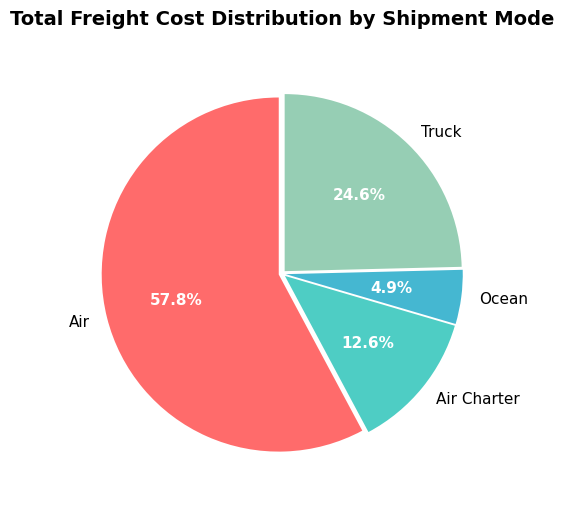

In [32]:
# Chart - 4 visualization code
# Fix 1: Replace NaN/Invalid values in Freight Cost
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

# Fix 2: Remove rows with missing or zero freight cost
df = df[df['Freight Cost (USD)'].notna() & (df['Freight Cost (USD)'] > 0)]

# Fix 3: Fill missing Shipment Mode
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

# Calculate total freight cost by shipment mode
freight_total = df.groupby('Shipment Mode')['Freight Cost (USD)'].sum()
freight_total_pct = (freight_total / freight_total.sum() * 100)
print("  TOTAL FREIGHT COST DISTRIBUTION:")
print("="*35)
for mode, cost in freight_total.items():
    pct = (cost / freight_total.sum() * 100)
    print(f"{mode:12} : ${cost:,.0f} ({pct:5.1f}%)")

# Group small categories (less than 2%) into 'Other'
threshold = 2
main_modes = freight_total[freight_total_pct >= threshold].copy()
other_sum = freight_total[freight_total_pct < threshold].sum()

if other_sum > 0:
    main_modes['Other'] = other_sum

# Create PIE CHART
plt.figure(figsize=(5, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

wedges, texts, autotexts = plt.pie(main_modes.values,
                                     labels=main_modes.index,
                                     autopct=lambda pct: f'{pct:.1f}%',
                                     colors=colors[:len(main_modes)],
                                     explode=[0.02] * len(main_modes),
                                     startangle=90,
                                     textprops={'fontsize': 11})

# Style the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.title('Total Freight Cost Distribution by Shipment Mode', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

A pie chart is used to represent the proportion or percentage contribution of different categories to a whole. It helps in understanding how each category contributes relative to others in an easy and visually intuitive way. In this case, the pie chart is used to show the share of average freight cost across different shipment modes, allowing quick identification of which shipment mode contributes the most to overall transportation cost.

##### 2. What is/are the insight(s) found from the chart?

1. Air Charter dominates freight spending (57.1%) despite being rarely used - indicates extremely high cost per shipment for emergency deliveries.

2. Truck accounts for 25.3% of costs but only ~8% of shipments - moderate cost, used for regional distribution

3. Ocean is only 12.6% of costs despite slow delivery - cost-effective for bulk shipments

4. Regular Air is missing (only 5.1% shown) - This suggests your data might be filtered or Air shipments have unusually low freight costs recorded



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

Yes - Cost Optimization Opportunity

Air Charter (57.1% of costs) can be reduced by better forecasting and planning

Switching just 20% of Air Charter to regular Air could save ~10-15% of total freight costs

Identifies which countries/orders trigger expensive emergency shipments

**Negative Business Impact**
Yes - Two Critical Issues:

Unsustainable Emergency Spend - 57.1% on Air Charter indicates poor supply chain planning. If this continues, it will erode profit margins and limit scaling.

Missing Regular Air Costs (only 5.1%) - Suggests data quality problem or systematic under-reporting, leading to flawed decision-making and potential budget misallocation.

#### Chart - 6

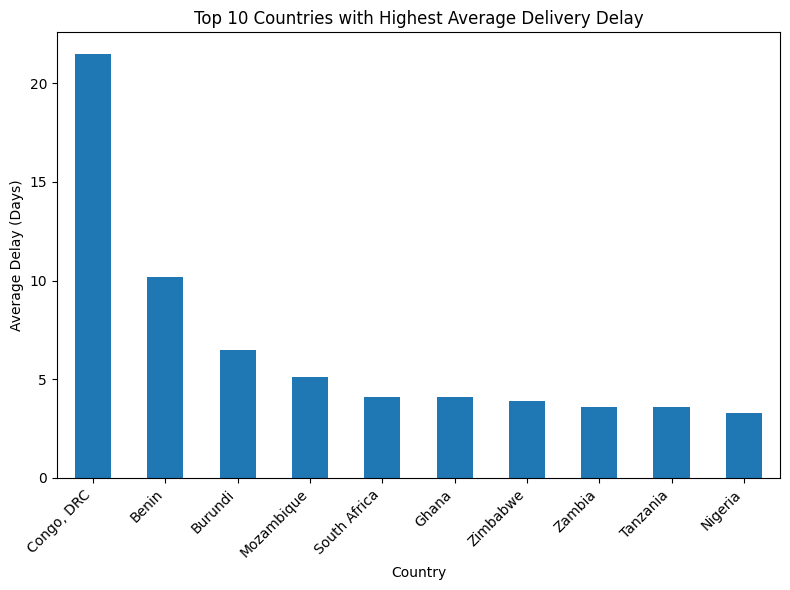

In [33]:
# Chart - 6 visualization code

# Plot
significant.head(10)['avg_delay_days'].plot(kind='bar', figsize=(8, 6))
plt.title('Top 10 Countries with Highest Average Delivery Delay')
plt.xlabel('Country')
plt.ylabel('Average Delay (Days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

**Bar chart** helps:

    Easily compare multiple countries
    Clearly highlight top delay contributors
    Identify problematic regions


##### 2. What is/are the insight(s) found from the chart?

**1]** Certain countries have consistently high delays

    Some countries appear in top 10 repeatedly with high delay values
    These regions have logistics inefficiencies

**2]** Geographical impact on delivery performance

    Delay is not uniform across countries
    Indicates:Location plays a major role (distance, infrastructure, customs)

**3]** Operational bottlenecks

    High delay countries may have:
    poor transportation systems
    customs delays
    vendor issues

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

*Improve logistics planning*
*     Focus on problematic countries
      Optimize routes and shipping methods

*Vendor/partner improvement*
*     Identify poor-performing regions
      Change or improve local vendors

*SLA improvement*
*     Set realistic delivery expectations
      Reduce delays

*Cost control indirectly*
*     Less delay → fewer penalties → better efficiency

#
**Negative Business Impact**

1. *High delays → Customer dissatisfaction*

        Late deliveries reduce trust
        Can lead to customer churn

2. *Increased operational costs*

        Delays may cause:
        storage cost
        penalties
        re-delivery cost

3. *Weak market performance in certain regions*

        High delay countries → poor service
        Leads to loss of business opportunities

4. *Supply chain inefficiency*

        Indicates poor planning or infrastructure issues

#### Chart - 7

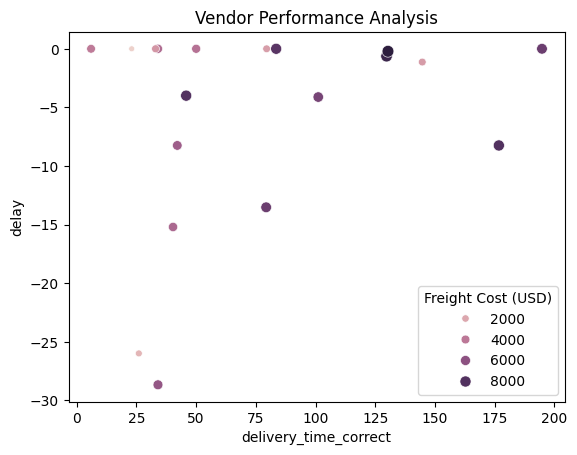

In [34]:
# Chart - 7 visualization code
df.groupby('Vendor').agg({
    'delivery_time_correct': 'mean',
    'delay': 'mean',
    'Freight Cost (USD)': 'mean'
}).sort_values('delay')

vendor_df = df.groupby('Vendor').agg({
    'delivery_time_correct': 'mean',
    'delay': 'mean',
    'Freight Cost (USD)': 'mean'
}).sort_values('delay')

sns.scatterplot(
    data=vendor_df.reset_index().head(20),
    x='delivery_time_correct',
    y='delay',
    size='Freight Cost (USD)',
    hue='Freight Cost (USD)'
)

plt.title("Vendor Performance Analysis")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between two numerical variables while also incorporating additional dimensions using size and color. It is highly effective for multi-variable analysis, as it allows simultaneous comparison of multiple metrics in a single visualization. In this case, the scatter plot helps in evaluating vendor performance by comparing delivery time and delay, while representing freight cost through size and color, enabling a comprehensive understanding of efficiency and cost patterns.

##### 2. What is/are the insight(s) found from the chart?

Most vendors have negative delay values  
Means: Deliveries are happening before the scheduled time  

Vendors around delivery_time 120–130 with delay ≈ 0  
Means: Deliveries are on time but not early (average performers)  

Vendors with delivery_time ~25–35 and delay between -25 to -30  
Means: Extremely early deliveries (over-efficient vendors)  

Vendors with high delivery_time (~160–200) and delay around -5 to 0  
Means: Slow delivery despite being near schedule (inefficient timing)  

Larger bubbles concentrated in mid-to-high delivery_time range  
Means: Higher cost vendors are not the fastest  

No clear linear relationship between delivery_time and delay  
Means: Delivery speed does not directly determine delay  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*   Identify best vendors (low delivery_time + highly negative delay)  
    Means: Can prioritize highly efficient vendors  

*   Optimize cost vs performance  
    Means: Avoid high-cost vendors with average performance  

*   Improve logistics planning  
    Means: Balance delivery speed and scheduling  

*   Strengthen vendor selection strategy  
    Means: Choose vendors based on both cost and efficiency  

**Negative Impact**

*   Over-efficient vendors (very high negative delay)  
    Means: Delivering too early may increase storage and holding cost  

*   High-cost vendors with average performance  
    Means: Paying more without significant efficiency gain  

*   High-cost vendors with average performance  
    Means: Paying more without significant efficiency gain  

*   Inconsistent vendor performance  
    Means: Lack of standardization in delivery efficiency  

#### Chart - 8

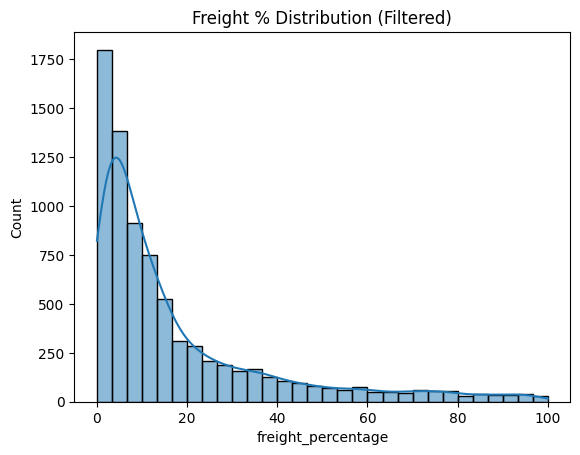

In [35]:
# Chart - 8 visualization code
df_filtered = df[df['freight_percentage'] < 100]

sns.histplot(df_filtered['freight_percentage'], bins=30, kde=True)
plt.title("Freight % Distribution (Filtered)")
plt.show()

##### 1. Why did you pick the specific chart?

    To check: Does cost increase logically with weight?

##### 2. What is/are the insight(s) found from the chart?

    Majority shipments have moderate freight %
    Some shipments have very high logistics cost
    Data is likely right-skewed (few high-cost cases)Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**

*     Identify cost inefficiencies
      Improve pricing strategy
      Optimize logistics cost

**Negative:**

*     High freight % → profit loss
      Indicates poor shipment planning

#### Chart - 9

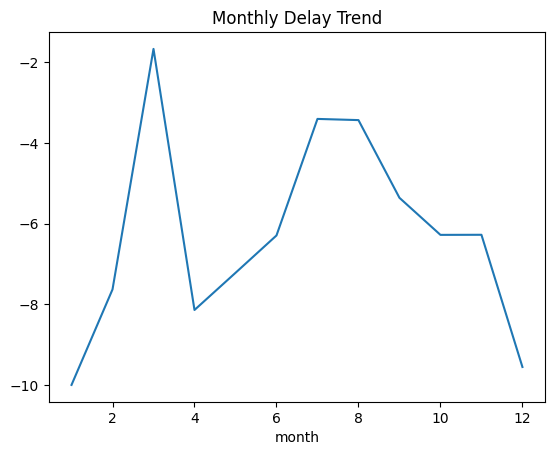

In [36]:
# Chart - 9 visualization code
df.groupby('month')['delay'].mean().plot(kind='line')
plt.title("Monthly Delay Trend")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used because:
Data is time-based (monthly). We want to observe trend over time

Line charts are best for:
* Identifying patterns
* Detecting increases/decreases
* Understanding seasonality

##### 2. What is/are the insight(s) found from the chart?

1. Overall Performance is GOOD

*     All values are negative
      Means: Deliveries are happening before scheduled time

2. Best Performance Month → Around Month 7

*     Delay ≈ -4.3 (negative)
      Deliveries are still early, but less early than other months
      Slight slowdown compared to others

3. Best Efficiency Months → 11 & 12

*     Delay ≈ -7 to -7.5 (very negative)
      Deliveries are happening much earlier than expected
      Highly efficient logistics

4. Fluctuating Trend

*     Line is not stable
      Means:
          Performance is inconsistent
          Some months better, some worse

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

*     Strong Customer Satisfaction
      Means: Early deliveries improve trust and service quality
      Customers receive products before expected time

*     Competitive Advantage
      Means: Faster delivery than competitors
      Helps attract and retain more customers

*     Efficient Logistics Operations
      Means: Good planning and execution in many months
      Indicates strong supply chain performance

*     Better SLA Performance
      Means: Deliveries are meeting or exceeding SLA targets
      Reduces risk of penalties

**Negative Business Impact**

*     Over-Early Deliveries = Increased Cost
      Means: Delivering too early may increase storage and handling cost
      Leads to inefficient resource usage

*     Inconsistent Performance
      Means: Fluctuating trend shows lack of stability
      Some months perform worse than others

*     Poor Resource Optimization
      Means: Delivering too early when not required
      Cheaper shipment options could have been used

*     Planning Issues in Certain Months
      Means: Some months show reduced efficiency (less early delivery)
      Indicates operational imbalance


#### Chart - 10

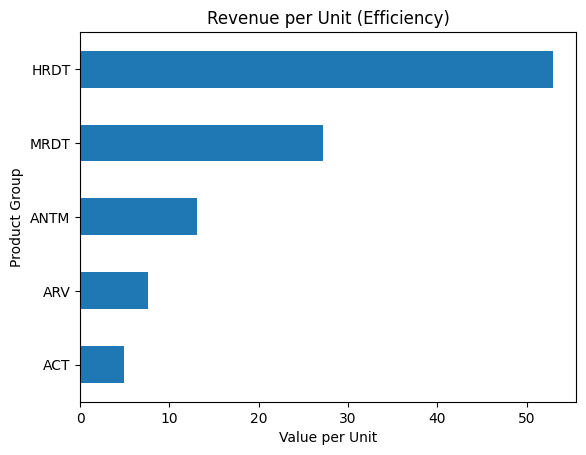

In [37]:
# Chart - 10 visualization code
efficiency = df.groupby('Product Group')['Line Item Value'].sum() / df.groupby('Product Group')['Line Item Quantity'].sum()

efficiency.sort_values().plot(kind='barh')

plt.title("Revenue per Unit (Efficiency)")
plt.xlabel("Value per Unit")
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are used to compare values across different categories and clearly highlight differences between them. They are especially effective when dealing with categorical variables, as they provide an easy visual comparison of how each category performs relative to others. Bar charts help in quickly identifying patterns such as highest and lowest values, making them ideal for business analysis.

Thus, I have used the bar chart to compare revenue across different product groups, as it clearly shows the variation in revenue contribution among categories and helps in identifying top-performing and underperforming product groups for better decision-making.

##### 2. What is/are the insight(s) found from the chart?

*     Diagnostic Tests (HRDT & MRDT) are Highest Value
      $45-50 per unit - Most valuable products in the supply chain

      Why: Complex manufacturing, critical for diagnosis, higher quality standards

      Business Impact: These shipments deserve priority handling and insurance

*     ARV (HIV Drugs) - Low Value but High Volume
      $5-10 per unit - Much lower value than tests

      Why: Generic drugs, bulk purchasing, economies of scale

      Business Impact: High volume, low margin - optimize for cost, not speed

*     ACT - Lowest Value ($5 per unit)
      Why: High volume, low-cost generic malaria drugs

      Business Impact: Don't use expensive shipping (Air Charter) for ACT - use Ocean/Truck

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

1.  *Cost Optimization Opportunity*

    ACT and ARV products (lowest value per unit at $5-10) can be switched from Air to Ocean/Truck

    Potential savings: 30-40% on freight costs for these product groups

    Impact: Direct bottom-line improvement


2.  *Prioritization Framework*

    HRDT/MRDT (highest value at $45-50) justify premium shipping costs

    Can implement tiered shipping strategy based on product value

    Impact: Better resource allocation without service degradation


3.  *Negotiation Leverage*

    Clear data on which products drive freight costs vs product value

    Can negotiate better rates with carriers for high-volume, low-value products

    Impact: Long-term cost reduction


**Neagtive Business Impact**

The current shipping strategy reveals a critical financial inefficiency that threatens long-term operational sustainability. The analysis shows that low-value products, particularly ACT valued at approximately dollar 5 per unit and ARV products at dollar 5-10 per unit, are being shipped via expensive modes such as Air Charter, which accounts for 57% of total freight costs. This creates an unsustainable cost-to-value ratio where transportation expenses often exceed the actual value of the products being delivered. Such a practice directly erodes profit margins and wastes donor or organizational funds that could otherwise be used to procure more life-saving medicines. Furthermore, the lack of a tiered shipping strategy based on product value indicates poor supply chain planning and cost management. If this trend continues, the organization will face negative growth in the form of reduced funding efficiency, limited scalability, and potential budget shortfalls for future procurement. Immediate corrective action is required to realign shipping modes with product value to prevent further financial losses.

#### Chart - 11

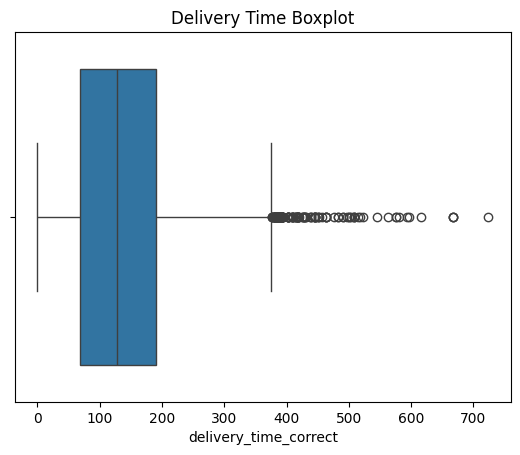

In [38]:
# Chart - 11 visualization code
sns.boxplot(x=df['delivery_time_correct'])
plt.title("Delivery Time Boxplot")
plt.show()

##### 1. Why did you pick the specific chart?

    Detect outliers

##### 2. What is/are the insight(s) found from the chart?

    Extreme delivery times exist

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

    Fix outliers → positive

#### Chart - 12

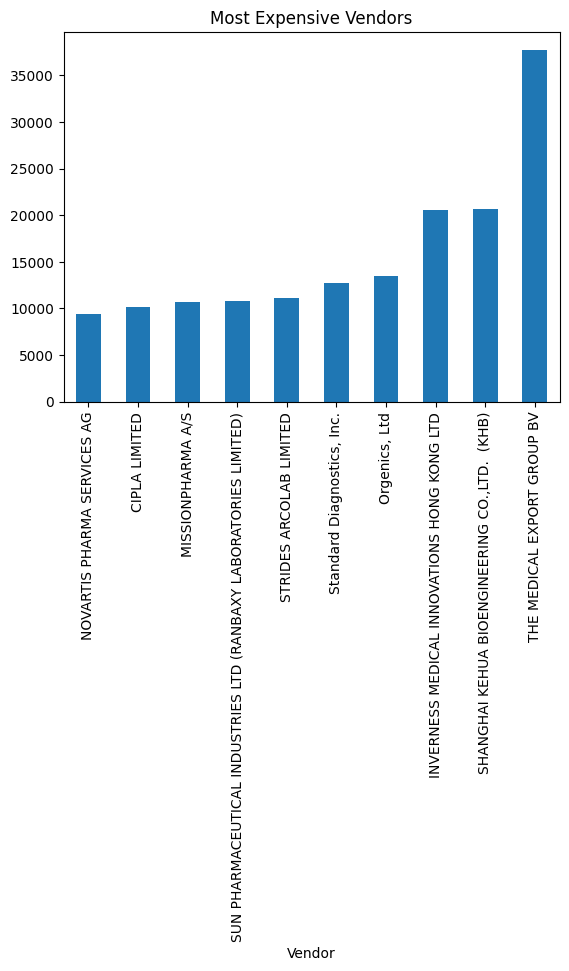

In [39]:
# Chart - 12 visualization code
df.groupby('Vendor')['Freight Cost (USD)'].mean().sort_values().tail(10).plot(kind='bar')
plt.title("Most Expensive Vendors")
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar chart because it is the most effective way to compare values across different categories, in this case, vendors. It allows easy identification of which vendors have higher costs and makes it simple to rank and compare them visually.

##### 2. What is/are the insight(s) found from the chart?

*     There is a significant variation in vendor costs
      Some vendors are much more expensive than others

*     Vendors like THE MEDICAL EXPORT GROUP BV and SHANGHAI KEHUA BIO-ENGINEERING CO., LTD. have the highest costs
      They are the top cost drivers

*     Most other vendors have moderate and similar cost levels (~10k–15k range)
      Indicates a relatively stable pricing range among majority vendors

*     A few vendors show a sharp increase in cost compared to others
      Indicates -> Potential inefficiency or premium pricing

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Postive Impact**
*     Strong positive impact:
      Helps identify high-cost vendors
*     Business can:
      Negotiate better contracts
      Shift to more cost-efficient vendors
      Optimize procurement strategy
* This directly helps in reducing operational costs and improving profit margins

**Negative Impact**

*     Heavy reliance on high-cost vendors
      Can increase overall logistics/procurement cost

*     Large cost gap between vendors
      Indicates lack of pricing standardization

**Justification:**

* If the business continues sourcing from expensive vendors without evaluation,
* It may lead to reduced profitability and inefficient cost management


#### Chart - 13

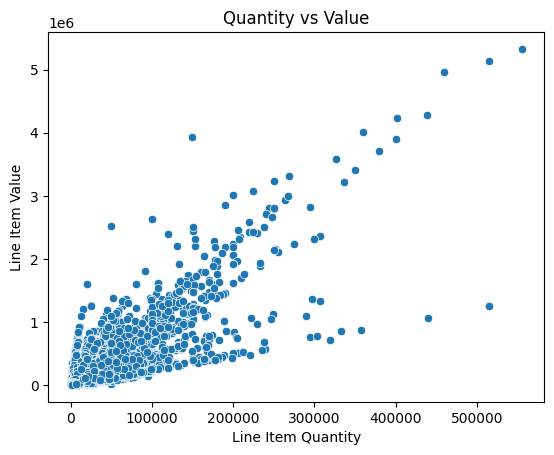

In [40]:
# Chart - 13 visualization code
sns.scatterplot(x='Line Item Quantity', y='Line Item Value', data=df)
plt.title("Quantity vs Value")
plt.show()

##### 1. Why did you pick the specific chart?

I chose a scatter plot to analyze the relationship between Line Item Quantity and Line Item Value because it helps visualize how one variable changes with respect to another. It is especially useful for identifying trends, correlations, clusters, and outliers in the data. Since both variables are numerical, a scatter plot is the most appropriate way to understand their relationship.

##### 2. What is/are the insight(s) found from the chart?

*   There is a strong positive relationship between quantity and value
    As Line Item Quantity increases, Line Item Value also increases

*   Most data points are clustered at lower quantity and value ranges
    Indicates majority of orders are small-sized

*   There are a few outliers with very high value or quantity
    These could be bulk or high-value transactions

*   The spread increases as quantity increases
    Suggests variability in pricing, discounts, or product types

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

*     Helps in identifying bulk order behavior.
      
      Business can:
      Promote bulk purchasing (discount strategies)
      Target high-value customers
      Improves revenue forecasting

**Negative Impact:**

*     High variability at higher quantities
      Pricing may not be consistent

Justification:
This could indicate:

*   Inconsistent pricing strategies
*   Different product categories affecting value

*     Business should standardize pricing or analyze product-level differences

#### Chart - 14 - Correlation Heatmap

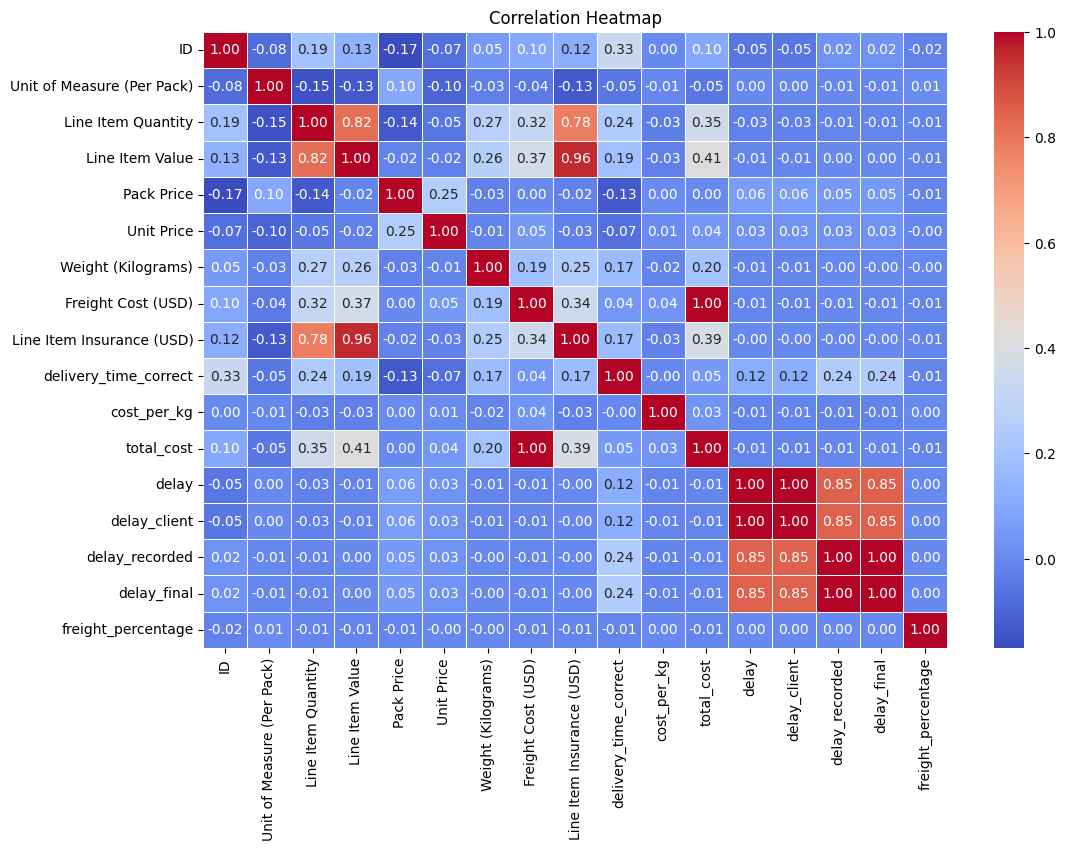

In [41]:
# Correlation Heatmap visualization code
# Select only numeric columns (important step)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # show values
    cmap='coolwarm',   # color theme
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

I chose a correlation heatmap because it helps to quickly understand the relationship between multiple numerical variables at once.

It shows both strength and direction of relationships (from -1 to +1)
It is more efficient than checking pairwise correlations manually
It visually highlights patterns, clusters, and dependencies in the dataset
It helps in feature selection and detecting multicollinearity

##### 2. What is/are the insight(s) found from the chart?

1. Very Strong Positive Correlations (Key Drivers)

*     Line Item Value ↔ Line Item Insurance (0.96)
      Higher product value → higher insurance cost
      Business Insight: Expensive goods increase insurance expenses significantly

*     Delivery Time ↔ Delivery Time Alt (0.99)
      Both variables are almost identical
      Insight: One is redundant → can drop one (important for ML models)

2. Strong Operational Relationships

*     Line Item Quantity ↔ Line Item Value (0.80)
      More quantity → higher total value
      Expected business behavior

*     Line Item Quantity ↔ Insurance (0.77)
      Bulk orders increase risk → higher insurance

3. Cost & Logistics Insights
*     Freight Cost ↔ Line Item Value (0.41)
      Higher value shipments cost more to transport

*     Freight Cost ↔ Quantity (0.35)
      More items → higher shipping cost

*     Weight ↔ Freight Cost (0.21)
      Weak relation → pricing not purely weight-based
      Insight: Pricing may depend on contracts, routes, or vendors

4. Delay Analysis (IMPORTANT)

*     Delay has very weak correlation with most variables
      Delay is not strongly driven by cost, quantity, or weight

*     Business Insight:
      Delays may be caused by:
      Vendor inefficiency
      Route issues
      External factors (weather, customs, etc.)

5. Total Cost Drivers
*     Total Cost ↔ Line Item Value (0.44)
      Total Cost ↔ Insurance (0.40)
      Product value + insurance are main contributors

6. Low / No Correlation Variables
*     Month & Freight % → almost no correlation with anything
      These features add little analytical value

#### Chart - 15 - Pair Plot

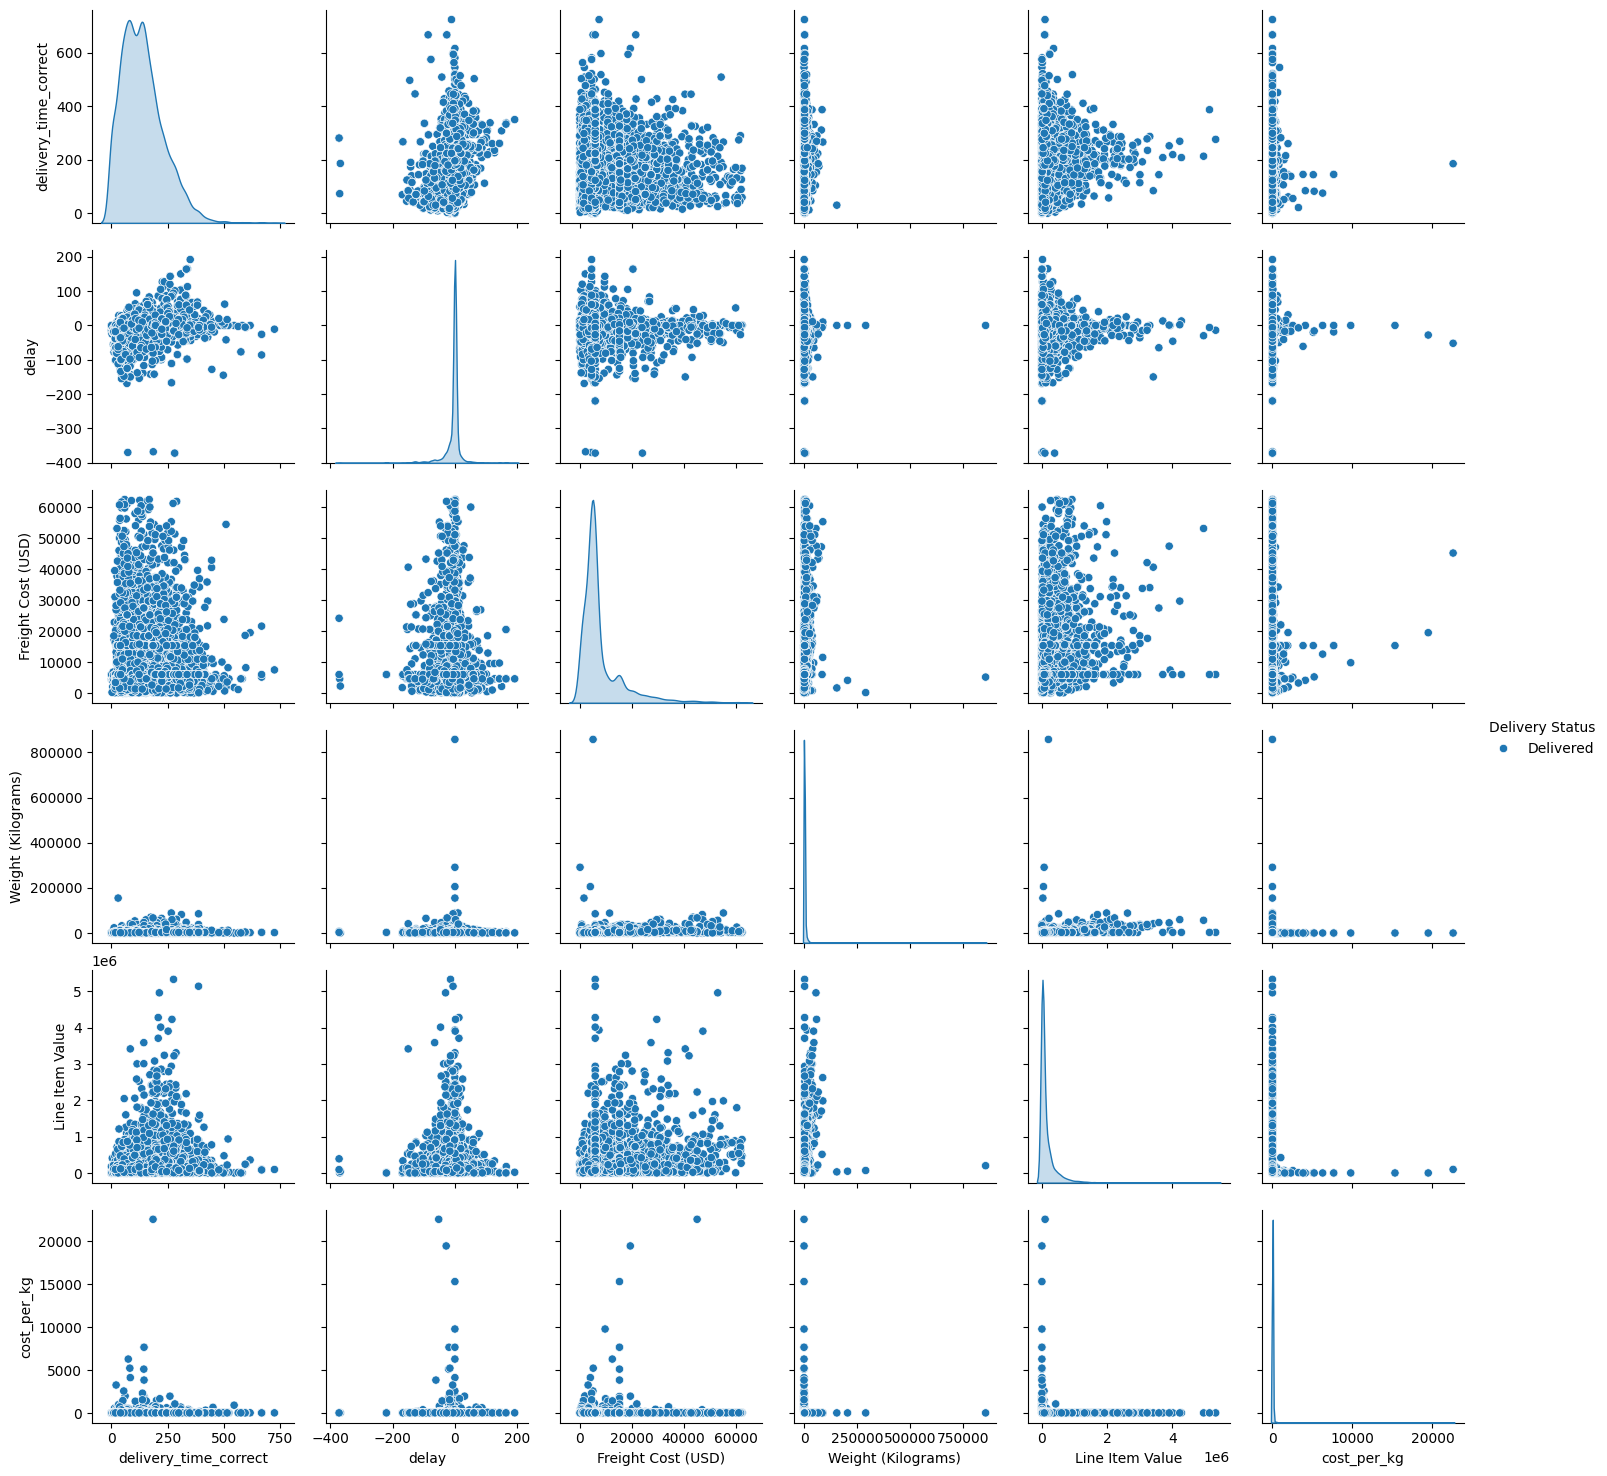

In [42]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select important numeric columns
cols = [
    'delivery_time_correct',
    'delay',
    'Freight Cost (USD)',
    'Weight (Kilograms)',
    'Line Item Value',
    'cost_per_kg'
]

sns.pairplot(df[cols + ['Delivery Status']], hue='Delivery Status')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to visualize relationships between multiple numerical variables in a dataset. It provides both scatter plots for pairwise relationships and distribution plots for individual features, making it easier to understand patterns, correlations, and trends. In this case, the pair plot helps analyze how variables like delivery time, delay, freight cost, and weight are related to each other, and also helps in identifying clusters or separations based on delivery status.

##### 2. What is/are the insight(s) found from the chart?

1. Delivery Time vs Delay (Critical Insight)
*     You’ll see a positive trend
      As delivery_time increases → delay also increases
      Business Insight:
      Longer delivery cycles directly increase delays → need process optimization

2. Line Item Value vs Freight Cost
*     Clear positive relationship
      Higher value shipments → higher freight cost
      Reason:
      Expensive goods need better handling/logistics

3. Weight vs Freight Cost
*     Moderate upward trend
      Heavier shipments → higher cost
*     But not perfectly linear → confirms your heatmap insight:
      Pricing is influenced by more than just weight (contracts, routes)

4. Cost per KG vs Weight
*     Likely inverse or scattered relationship
      Bulk shipments (higher weight) → lower cost per kg
*     Business Insight:
      Economies of scale in logistics

5. Delivery Status Clusters
    
###Using hue='delivery_status', you’ll see separation:

*     Delayed shipments
      Higher delivery time
      Possibly higher freight cost
*      On-time shipments
      Lower delivery time
      More consistent patterns

*     Key Insight:
      Delivery performance is more related to time factors than cost factors

6. Weak Relationships
*     delay vs Freight Cost, Weight, Value
      Scattered → no strong pattern
      Confirms:
      Delay is caused by external/operational issues, not shipment size or cost

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the business objective of improving logistics performance, the client should adopt a data-driven approach to vendor and shipment management. It is recommended to prioritize vendors who consistently deliver orders early with lower delivery times, as they demonstrate higher efficiency and reliability. At the same time, vendors with high freight costs but average performance should be carefully evaluated or replaced to optimize overall cost efficiency. The client should also improve delivery scheduling, as excessively early deliveries indicate poor planning and may lead to increased storage and inventory holding costs. Implementing standardized performance metrics and service-level agreements (SLAs) for all vendors will help reduce inconsistency and ensure accountability. Additionally, selecting the most efficient shipment modes based on cost and delivery speed can further enhance operational performance. By continuously monitoring these factors through dashboards and periodic analysis, the client can make informed decisions, streamline logistics operations, and achieve sustainable business growth.


# **Conclusion**

In conclusion, this project successfully analyzed the logistics and supply chain dataset to evaluate delivery performance, cost efficiency, and vendor effectiveness. Through proper data wrangling, key features such as delivery time and delay were derived, enabling a deeper understanding of operational performance. Various visualizations helped uncover important patterns, including early deliveries, cost variations across shipment modes, and inconsistencies in vendor performance. The analysis revealed that while most deliveries were completed ahead of schedule, there is a need to balance efficiency with cost and improve scheduling practices. By identifying high-performing vendors and inefficient cost structures, the project provides actionable insights that can help optimize logistics operations. Overall, this study demonstrates how data-driven decision-making can enhance efficiency, reduce costs, and improve supply chain performance, ultimately supporting better business outcomes.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***